# 🌍 Global Air Pollution — Clustering Analysis
**ML Module Project | Unsupervised Learning**

> **Objective:** Discover natural pollution archetypes across world cities using K-Means and DBSCAN clustering on AQI measurements across four major pollutants — CO, Ozone, NO₂, and PM2.5.

**Dataset:** Global Air Pollution Dataset (Kaggle)  
**Rows:** 23,463 cities | **Columns:** 12 | **Task:** Clustering (Unsupervised)

---


## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## 2. Load & Inspect Dataset

In [6]:
df = pd.read_csv('global_air_pollution_dataset.csv')

print("Shape:", df.shape)
print()
print("Columns:", df.columns.tolist())
print()
df.head(10)


FileNotFoundError: [Errno 2] No such file or directory: 'global_air_pollution_dataset.csv'

In [7]:
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())


Data Types:


NameError: name 'df' is not defined

## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistical Summary


In [4]:
numerical_cols = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
df[numerical_cols].describe().round(2)


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.00,23463.00,23463.00,23463.00,23463.00
mean,72.01,1.37,35.19,3.06,68.52
std,56.06,1.83,28.10,5.25,54.80
min,6.00,0.00,0.00,0.00,0.00
25%,39.00,1.00,21.00,0.00,35.00
50%,55.00,1.00,31.00,1.00,54.00
75%,79.00,1.00,40.00,4.00,79.00
max,500.00,133.00,235.00,91.00,500.00


### 3.2 AQI Category Distribution

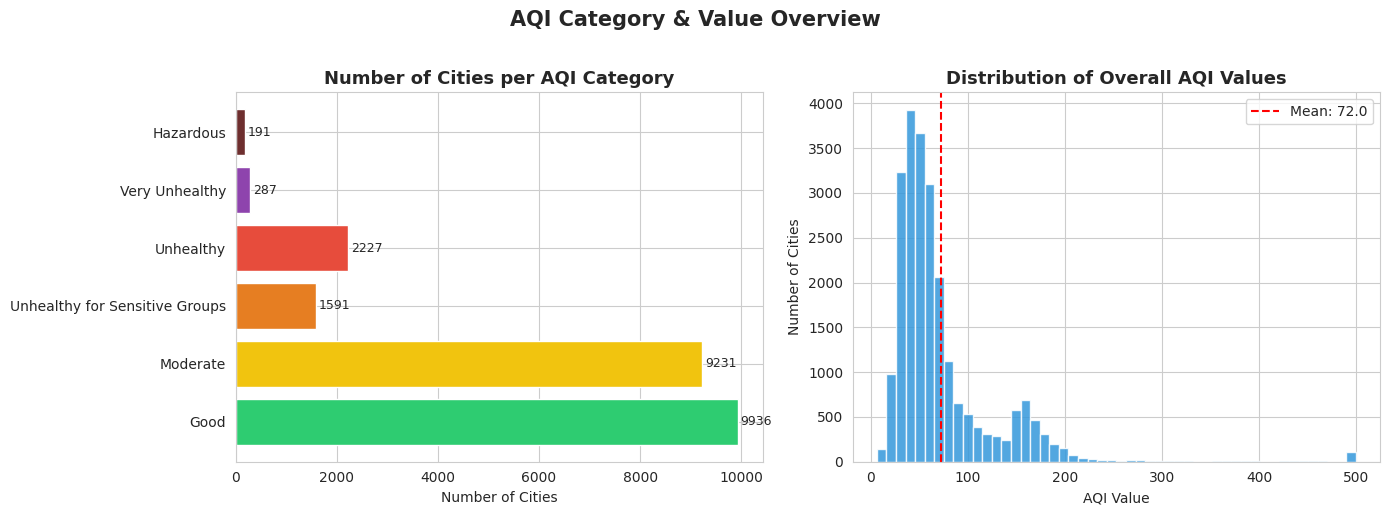

Mean AQI: 72.01 | Median AQI: 55.00 | Max: 500


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category counts
category_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 
                  'Unhealthy', 'Very Unhealthy', 'Hazardous']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad', '#6e2f2f']

counts = df['AQI Category'].value_counts().reindex(category_order)
axes[0].barh(category_order, counts.values, color=colors)
axes[0].set_title('Number of Cities per AQI Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Cities')
for i, v in enumerate(counts.values):
    axes[0].text(v + 50, i, str(v), va='center', fontsize=9)

# AQI Value distribution
axes[1].hist(df['AQI Value'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Overall AQI Values', fontsize=13, fontweight='bold')
axes[1].set_xlabel('AQI Value')
axes[1].set_ylabel('Number of Cities')
axes[1].axvline(df['AQI Value'].mean(), color='red', linestyle='--', label=f"Mean: {df['AQI Value'].mean():.1f}")
axes[1].legend()

plt.suptitle('AQI Category & Value Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/01_aqi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean AQI: {df['AQI Value'].mean():.2f} | Median AQI: {df['AQI Value'].median():.2f} | Max: {df['AQI Value'].max()}")


### 3.3 Pollutant AQI Distributions

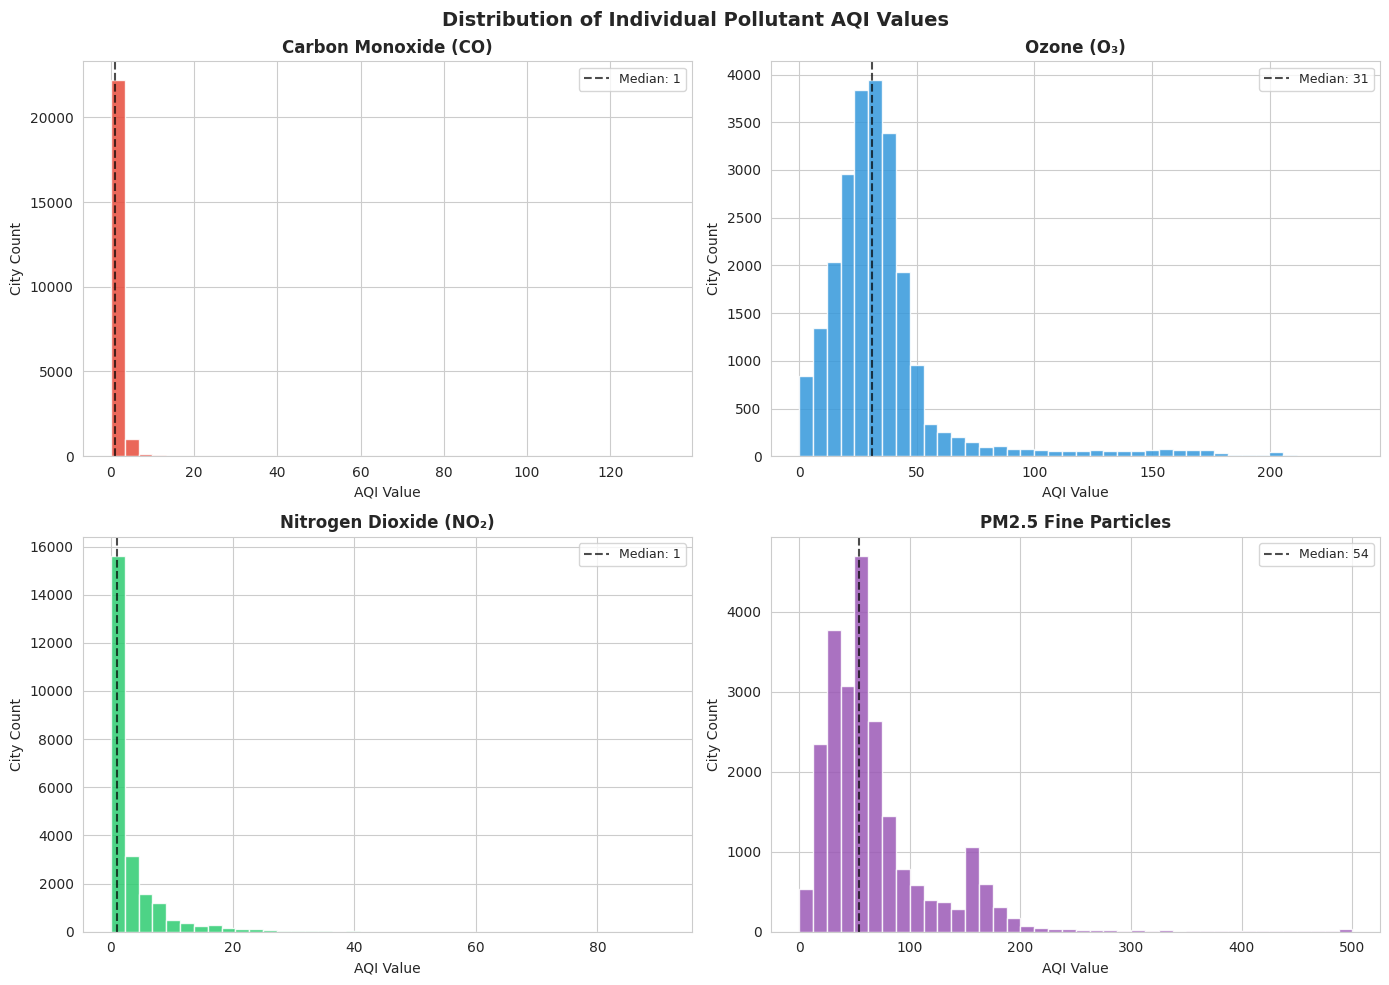

In [6]:
import os
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pollutants = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
poll_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
poll_labels = ['Carbon Monoxide (CO)', 'Ozone (O₃)', 'Nitrogen Dioxide (NO₂)', 'PM2.5 Fine Particles']

for ax, col, color, label in zip(axes.flatten(), pollutants, poll_colors, poll_labels):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('AQI Value')
    ax.set_ylabel('City Count')
    ax.axvline(df[col].median(), color='black', linestyle='--', alpha=0.7,
               label=f'Median: {df[col].median():.0f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Individual Pollutant AQI Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_pollutant_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Correlation Heatmap

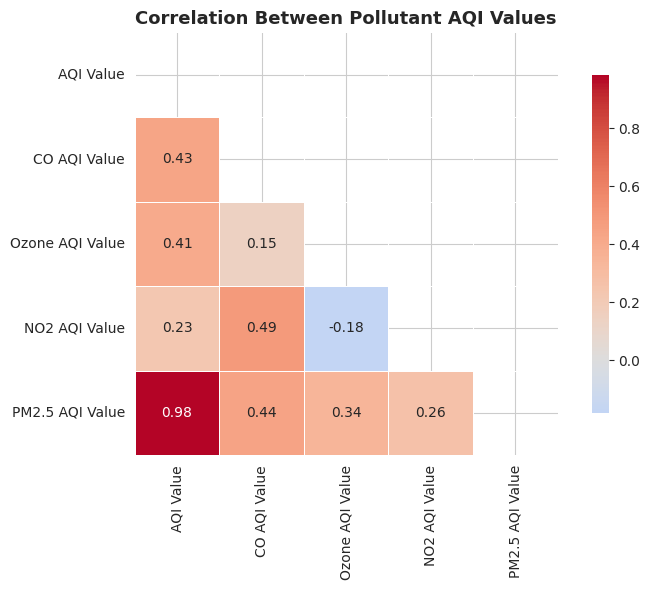

Key Insight: PM2.5 and overall AQI have the strongest correlation — PM2.5 is the dominant pollutant globally.


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, square=True, mask=mask,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Between Pollutant AQI Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key Insight: PM2.5 and overall AQI have the strongest correlation — PM2.5 is the dominant pollutant globally.")


### 3.5 Top 20 Most Polluted Cities

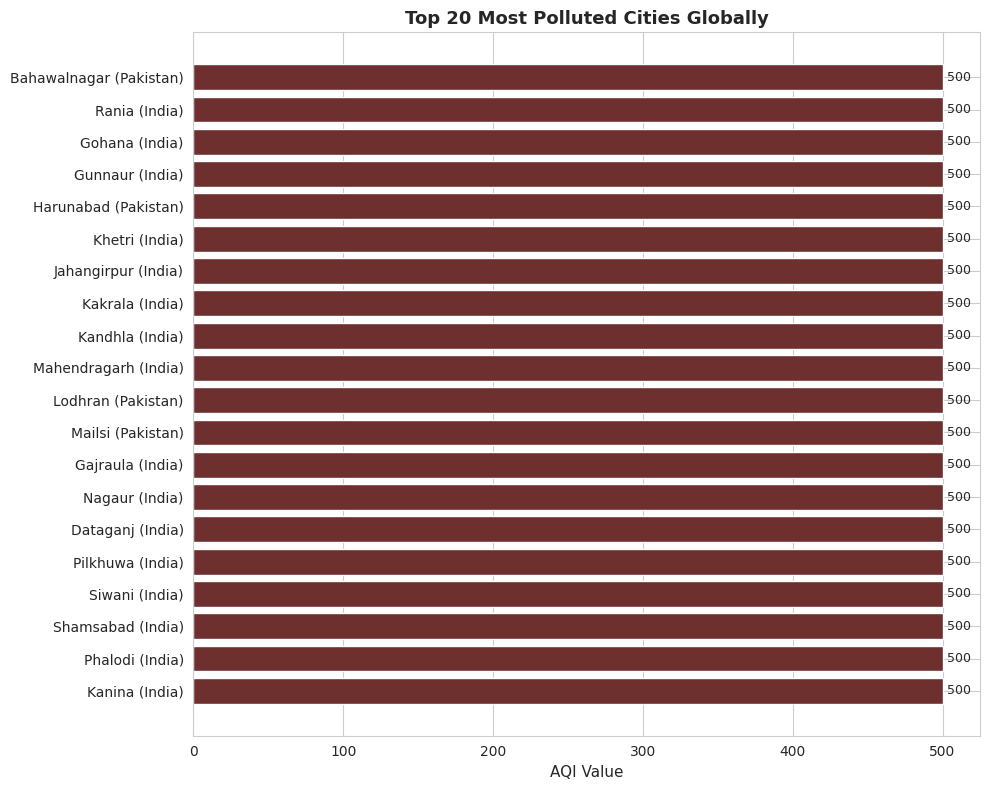

 Country         City  AQI Value AQI Category  PM2.5 AQI Value
Pakistan Bahawalnagar        500    Hazardous              466
   India        Rania        500    Hazardous              464
   India       Gohana        500    Hazardous              500
   India      Gunnaur        500    Hazardous              500
Pakistan    Harunabad        500    Hazardous              443
   India       Khetri        500    Hazardous              376
   India  Jahangirpur        500    Hazardous              493
   India      Kakrala        500    Hazardous              478
   India      Kandhla        500    Hazardous              500
   India Mahendragarh        500    Hazardous              435
Pakistan      Lodhran        500    Hazardous              364
Pakistan       Mailsi        500    Hazardous              386
   India     Gajraula        500    Hazardous              500
   India       Nagaur        500    Hazardous              426
   India     Dataganj        500    Hazardous          

In [8]:
top20 = df.dropna(subset=['City']).nlargest(20, 'AQI Value')[['Country', 'City', 'AQI Value', 'AQI Category', 'PM2.5 AQI Value']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20['City'] + ' (' + top20['Country'].fillna('N/A') + ')',
               top20['AQI Value'],
               color=['#6e2f2f' if v >= 300 else '#8e44ad' if v >= 200 else '#e74c3c'
                      for v in top20['AQI Value']])
ax.set_xlabel('AQI Value', fontsize=11)
ax.set_title('Top 20 Most Polluted Cities Globally', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, top20['AQI Value']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plots/04_top20_polluted.png', dpi=150, bbox_inches='tight')
plt.show()
print(top20.to_string(index=False))


### 3.6 Pollutant Scatter Plots

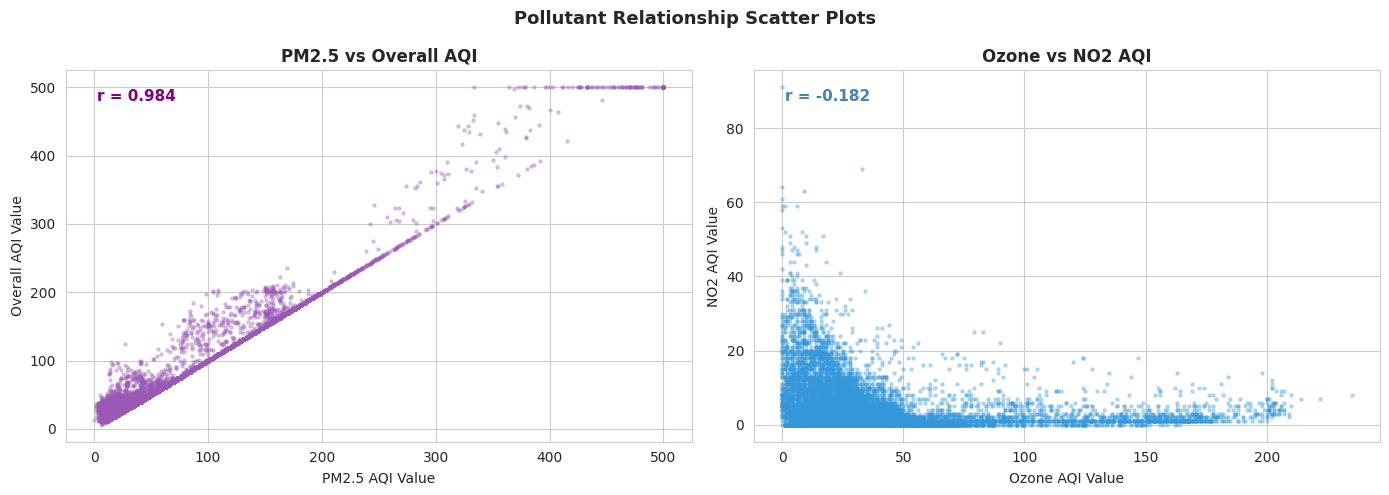

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['PM2.5 AQI Value'], df['AQI Value'], alpha=0.3, s=5, color='#9b59b6')
axes[0].set_xlabel('PM2.5 AQI Value')
axes[0].set_ylabel('Overall AQI Value')
axes[0].set_title('PM2.5 vs Overall AQI', fontweight='bold')
corr1 = df['PM2.5 AQI Value'].corr(df['AQI Value'])
axes[0].text(0.05, 0.95, f'r = {corr1:.3f}', transform=axes[0].transAxes,
             fontsize=11, va='top', color='purple', fontweight='bold')

axes[1].scatter(df['Ozone AQI Value'], df['NO2 AQI Value'], alpha=0.3, s=5, color='#3498db')
axes[1].set_xlabel('Ozone AQI Value')
axes[1].set_ylabel('NO2 AQI Value')
axes[1].set_title('Ozone vs NO2 AQI', fontweight='bold')
corr2 = df['Ozone AQI Value'].corr(df['NO2 AQI Value'])
axes[1].text(0.05, 0.95, f'r = {corr2:.3f}', transform=axes[1].transAxes,
             fontsize=11, va='top', color='steelblue', fontweight='bold')

plt.suptitle('Pollutant Relationship Scatter Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Data Preprocessing

### 4.1 Handle Missing Values & Select Features


In [10]:
# Drop rows with missing City (only 1 row)
df_clean = df.dropna(subset=['City']).copy()

# Fill missing Country with 'Unknown'
df_clean['Country'] = df_clean['Country'].fillna('Unknown')

print(f"Rows after cleaning: {len(df_clean)} (removed {len(df) - len(df_clean)} rows)")
print()

# Feature selection — only the 5 numerical AQI columns for clustering
features = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
X = df_clean[features].copy()
print("Features selected for clustering:")
for f in features:
    print(f"  - {f}")


Rows after cleaning: 23462 (removed 1 rows)

Features selected for clustering:
  - AQI Value
  - CO AQI Value
  - Ozone AQI Value
  - NO2 AQI Value
  - PM2.5 AQI Value


### 4.2 StandardScaler — Why It Matters

In [11]:
print("Feature ranges BEFORE scaling:")
print(X.describe().loc[['min', 'max', 'mean', 'std']].round(2))
print()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Feature ranges AFTER scaling (mean≈0, std≈1):")
print(X_scaled_df.describe().loc[['min', 'max', 'mean', 'std']].round(3))
print()
print("✅ Scaling complete — all features now contribute equally to distance calculations")


Feature ranges BEFORE scaling:
      AQI Value  CO AQI Value  Ozone AQI Value  NO2 AQI Value  PM2.5 AQI Value
min        6.00          0.00             0.00           0.00             0.00
max      500.00        133.00           235.00          91.00           500.00
mean      72.01          1.37            35.19           3.06            68.52
std       56.06          1.83            28.10           5.25            54.80

Feature ranges AFTER scaling (mean≈0, std≈1):
      AQI Value  CO AQI Value  Ozone AQI Value  NO2 AQI Value  PM2.5 AQI Value
min      -1.178        -0.747           -1.252         -0.583           -1.250
max       7.635        71.849            7.111         16.737            7.874
mean      0.000         0.000           -0.000          0.000            0.000
std       1.000         1.000            1.000          1.000            1.000

✅ Scaling complete — all features now contribute equally to distance calculations


## 5. Finding Optimal Number of Clusters (K)

We use two methods:
- **Elbow Method** — plot inertia vs K, look for the 'elbow' bend
- **Silhouette Score** — measures cluster cohesion & separation (higher = better)


In [12]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f"K={k:2d} | Inertia: {km.inertia_:>12,.1f} | Silhouette: {silhouette_score(X_scaled, labels):.4f}")


K= 2 | Inertia:     77,173.0 | Silhouette: 0.6099


K= 3 | Inertia:     60,420.8 | Silhouette: 0.6117


K= 4 | Inertia:     51,713.3 | Silhouette: 0.5881


K= 5 | Inertia:     43,706.8 | Silhouette: 0.5102


K= 6 | Inertia:     36,681.6 | Silhouette: 0.5272


K= 7 | Inertia:     31,472.4 | Silhouette: 0.4831


K= 8 | Inertia:     28,143.6 | Silhouette: 0.2887


K= 9 | Inertia:     25,113.3 | Silhouette: 0.2967


K=10 | Inertia:     22,773.5 | Silhouette: 0.3067


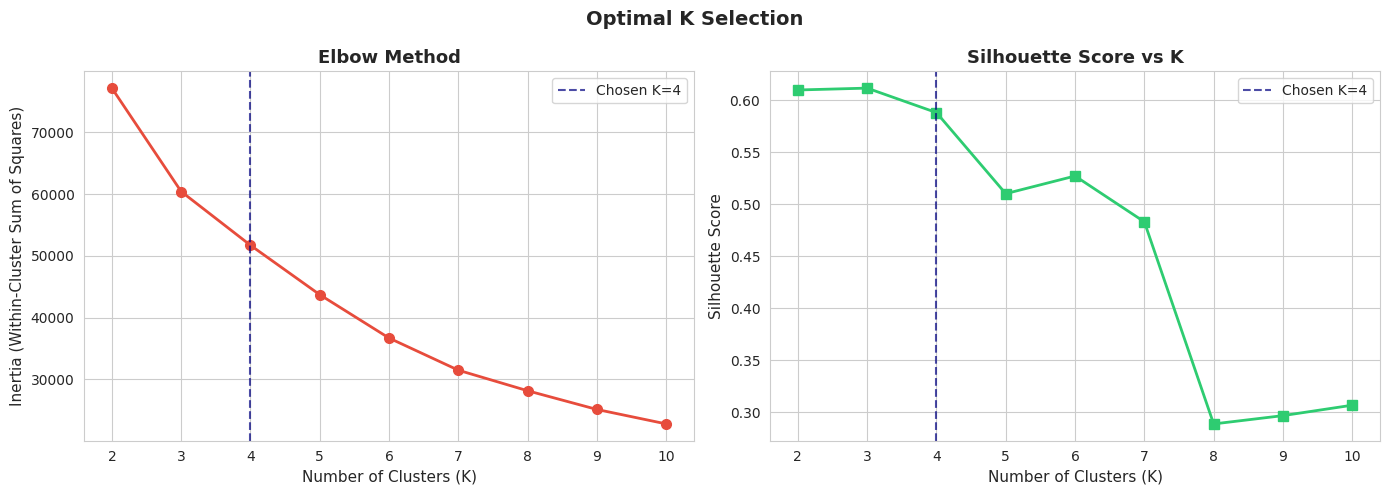


✅ Based on Elbow + Silhouette analysis, K=4 is selected as optimal.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertias, marker='o', color='#e74c3c', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(K_range))
best_k = 4
axes[0].axvline(best_k, color='navy', linestyle='--', alpha=0.7, label=f'Chosen K={best_k}')
axes[0].legend()

# Silhouette
axes[1].plot(list(K_range), silhouettes, marker='s', color='#2ecc71', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xticks(list(K_range))
axes[1].axvline(best_k, color='navy', linestyle='--', alpha=0.7, label=f'Chosen K={best_k}')
axes[1].legend()

plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Based on Elbow + Silhouette analysis, K=4 is selected as optimal.")


## 6. K-Means Clustering (K=4)


In [14]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['KMeans_Cluster'] = km_final.fit_predict(X_scaled)

# Cluster sizes
cluster_counts = df_clean['KMeans_Cluster'].value_counts().sort_index()
print("Cluster Sizes:")
for c, cnt in cluster_counts.items():
    print(f"  Cluster {c}: {cnt:,} cities ({cnt/len(df_clean)*100:.1f}%)")

final_silhouette = silhouette_score(X_scaled, df_clean['KMeans_Cluster'])
print(f"\nFinal Silhouette Score (K=4): {final_silhouette:.4f}")


Cluster Sizes:
  Cluster 0: 19,019 cities (81.1%)
  Cluster 1: 1,934 cities (8.2%)
  Cluster 2: 1,476 cities (6.3%)
  Cluster 3: 1,033 cities (4.4%)



Final Silhouette Score (K=4): 0.5881


### 6.1 Cluster Centroid Analysis — Naming the Clusters

In [15]:
# Centroids in original scale
centroids_df = df_clean.groupby('KMeans_Cluster')[features].mean().round(2)
centroids_df['City Count'] = df_clean['KMeans_Cluster'].value_counts().sort_index()

print("Cluster Centroids (Original Scale):")
print(centroids_df.to_string())
print()

# Assign meaningful names based on centroid values
cluster_names = {
    0: '🟢 Clean / Low Pollution',
    1: '🟡 Moderate / Mixed Pollution',
    2: '🔴 PM2.5 Dominated / Severely Polluted',
    3: '🟠 Ozone Dominated / Traffic/Industrial'
}

# Sort clusters by AQI Value to auto-assign names correctly
sorted_clusters = centroids_df['AQI Value'].sort_values().index.tolist()
auto_names = {
    sorted_clusters[0]: '🟢 Clean / Low Pollution',
    sorted_clusters[1]: '🟡 Moderate / Mixed Pollution',
    sorted_clusters[2]: '🟠 High AQI / Industrial-Traffic',
    sorted_clusters[3]: '🔴 Severely Polluted / PM2.5 Dominated'
}

df_clean['Cluster_Name'] = df_clean['KMeans_Cluster'].map(auto_names)

print("Cluster Name Assignments:")
for k, name in auto_names.items():
    print(f"  Cluster {k} → {name} | Avg AQI: {centroids_df.loc[k, 'AQI Value']}")


Cluster Centroids (Original Scale):
                AQI Value  CO AQI Value  Ozone AQI Value  NO2 AQI Value  PM2.5 AQI Value  City Count
KMeans_Cluster                                                                                      
0                   51.45          1.00            30.22           2.01            48.40       19019
1                  181.63          1.57            41.97           1.83           177.85        1934
2                  125.00          4.57            14.93          18.57           124.96        1476
3                  169.63          3.29           143.03           2.67           153.55        1033

Cluster Name Assignments:
  Cluster 0 → 🟢 Clean / Low Pollution | Avg AQI: 51.45
  Cluster 2 → 🟡 Moderate / Mixed Pollution | Avg AQI: 125.0
  Cluster 3 → 🟠 High AQI / Industrial-Traffic | Avg AQI: 169.63
  Cluster 1 → 🔴 Severely Polluted / PM2.5 Dominated | Avg AQI: 181.63


### 6.2 Cluster Distribution Bar Chart

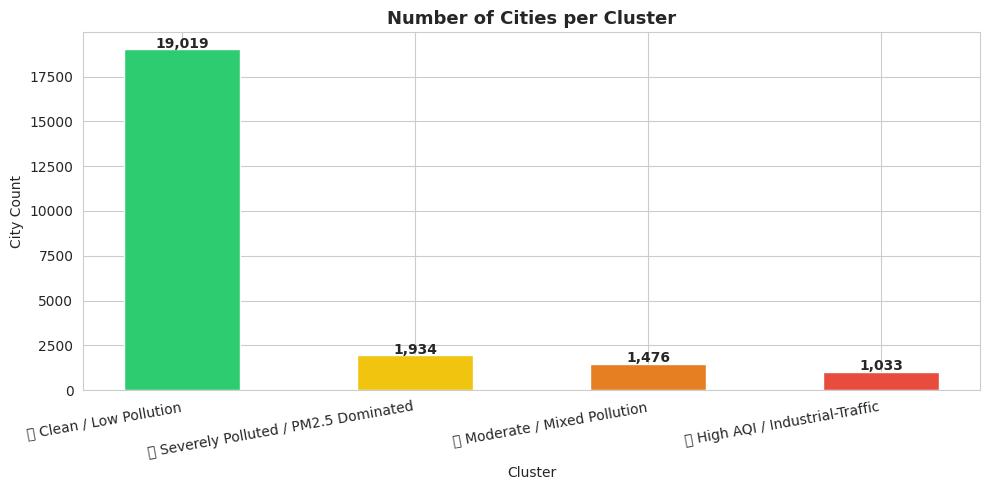

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
cluster_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
sorted_names = [auto_names[k] for k in sorted(auto_names.keys())]
counts_sorted = [cluster_counts[k] for k in sorted(auto_names.keys())]

bars = ax.bar(sorted_names, counts_sorted, color=cluster_colors, edgecolor='white', width=0.5)
ax.set_title('Number of Cities per Cluster', fontsize=13, fontweight='bold')
ax.set_ylabel('City Count')
ax.set_xlabel('Cluster')
for bar, count in zip(bars, counts_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.savefig('plots/07_cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Cluster Centroid Heatmap

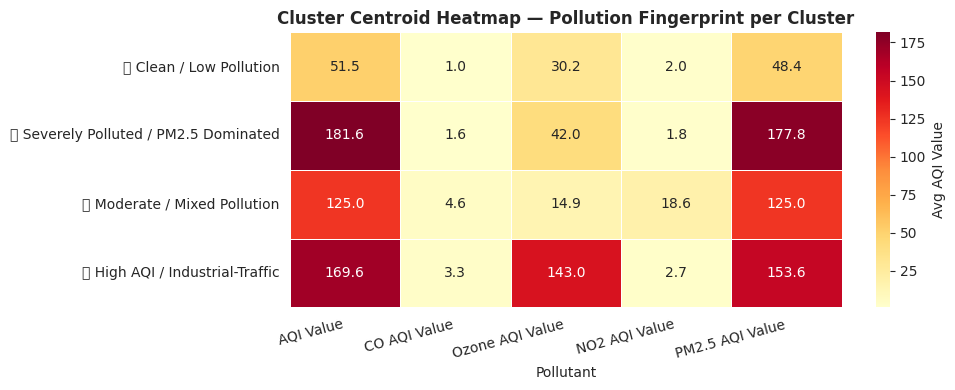

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
heatmap_data = centroids_df[features].loc[sorted(auto_names.keys())]
heatmap_data.index = [auto_names[k] for k in sorted(auto_names.keys())]

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg AQI Value'})
ax.set_title('Cluster Centroid Heatmap — Pollution Fingerprint per Cluster',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Pollutant')
plt.yticks(rotation=0)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('plots/08_centroid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4 Radar Chart — Pollution Fingerprint per Cluster

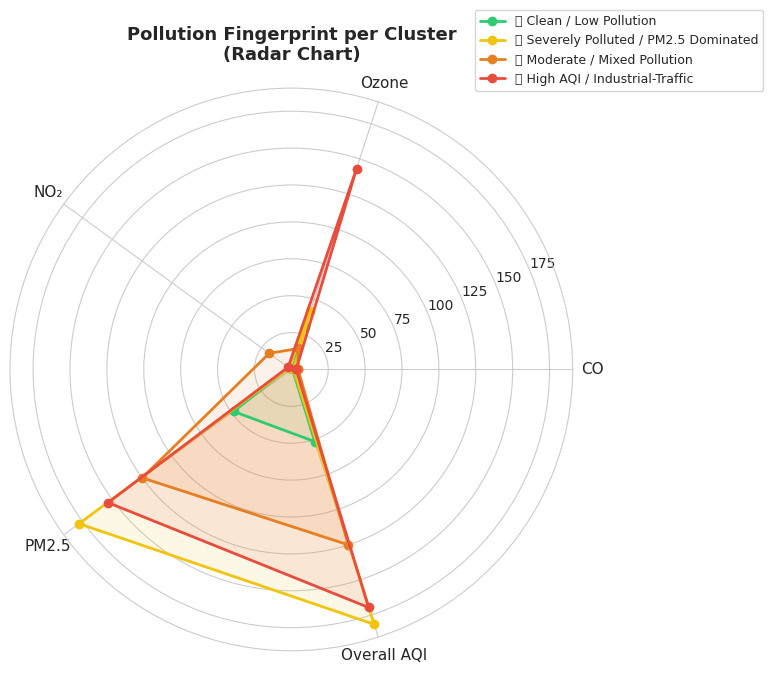

In [18]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm

radar_features = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value', 'AQI Value']
N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

for idx, k in enumerate(sorted(auto_names.keys())):
    values = centroids_df.loc[k, radar_features].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=auto_names[k], color=radar_colors[idx])
    ax.fill(angles, values, alpha=0.1, color=radar_colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['CO', 'Ozone', 'NO₂', 'PM2.5', 'Overall AQI'], fontsize=11)
ax.set_title('Pollution Fingerprint per Cluster\n(Radar Chart)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('plots/09_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.5 PCA Scatter — Clusters in 2D

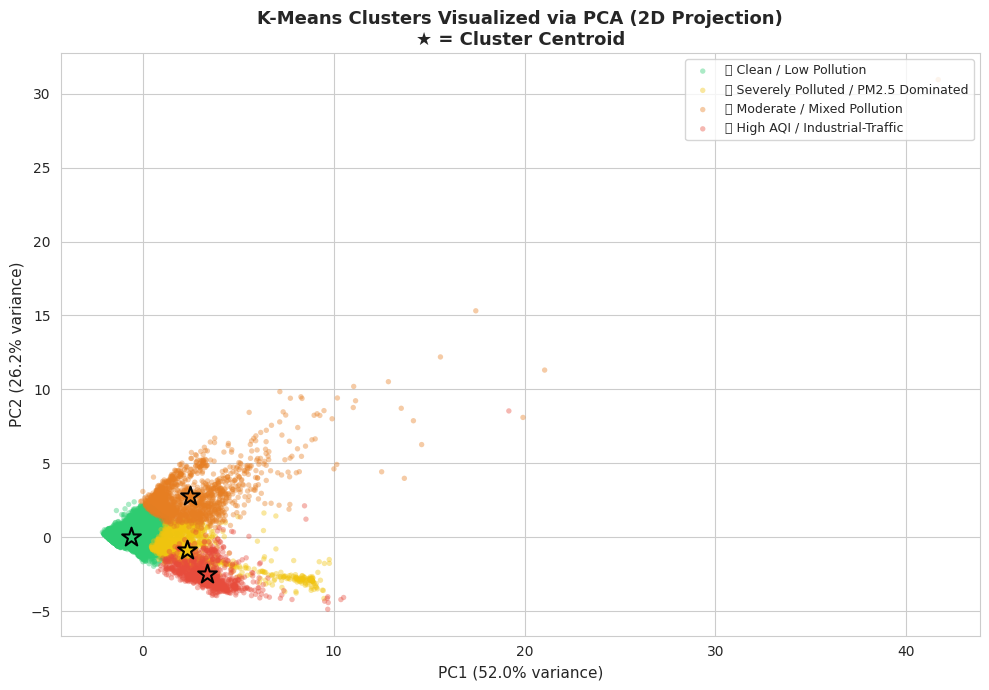

Total variance explained by 2 PCs: 78.2%


In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

for idx, k in enumerate(sorted(auto_names.keys())):
    mask = df_clean['KMeans_Cluster'] == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=scatter_colors[idx], label=auto_names[k],
               alpha=0.4, s=15, edgecolors='none')

# Plot centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
for idx, k in enumerate(sorted(auto_names.keys())):
    ax.scatter(centroids_pca[k, 0], centroids_pca[k, 1],
               c=scatter_colors[idx], s=200, marker='*',
               edgecolors='black', linewidths=1.5, zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('K-Means Clusters Visualized via PCA (2D Projection)\n★ = Cluster Centroid',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('plots/10_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%")


### 6.6 Top Cities per Cluster

In [20]:
print("Sample Cities per Cluster:\n")
for k in sorted(auto_names.keys()):
    cluster_df = df_clean[df_clean['KMeans_Cluster'] == k].nlargest(5, 'AQI Value')
    print(f"{'='*60}")
    print(f"  {auto_names[k]}")
    print(f"{'='*60}")
    print(cluster_df[['Country', 'City', 'AQI Value', 'PM2.5 AQI Value', 'Ozone AQI Value']].to_string(index=False))
    print()


Sample Cities per Cluster:

  🟢 Clean / Low Pollution
                           Country              City  AQI Value  PM2.5 AQI Value  Ozone AQI Value
                           Somalia           Qandala        120              120               20
                            Mexico Mineral Del Monte        119              119               15
Venezuela (Bolivarian Republic of)         Maracaibo        118              118               17
                            Mexico  General Escobedo        118              118               12
                           Namibia        Walvis Bay        118              118               19

  🔴 Severely Polluted / PM2.5 Dominated
 Country         City  AQI Value  PM2.5 AQI Value  Ozone AQI Value
Pakistan Bahawalnagar        500              466               38
   India        Rania        500              464               40
   India       Gohana        500              500               47
   India      Gunnaur        500              500

## 7. Agglomerative Clustering

Agglomerative Clustering is a hierarchical clustering algorithm.

It starts with each data point as an individual cluster and repeatedly merges the closest clusters until the desired number of clusters is reached.

In [ ]:
# Agglomerative Clustering with K=4
agg = AgglomerativeClustering(n_clusters=4)

df_clean['Agglomerative_Cluster'] = agg.fit_predict(X_scaled)

# Cluster sizes
agg_counts = df_clean['Agglomerative_Cluster'].value_counts().sort_index()

print("Agglomerative Cluster Sizes:")
for c, cnt in agg_counts.items():
    print(f"  Cluster {c}: {cnt:,} cities ({cnt/len(df_clean)*100:.1f}%)")

# Silhouette Score
agg_silhouette = silhouette_score(
    X_scaled,
    df_clean['Agglomerative_Cluster']
)

print(f"\nAgglomerative Silhouette Score (K=4): {agg_silhouette:.4f}")

### 7.1 Agglomerative Cluster Analysis

In [ ]:
# Cluster means in original scale
agg_centroids_df = df_clean.groupby(
    'Agglomerative_Cluster'
)[features].mean().round(2)

agg_centroids_df['City Count'] = (
    df_clean['Agglomerative_Cluster']
    .value_counts()
    .sort_index()
)

print("Agglomerative Cluster Profiles:")
print(agg_centroids_df.to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_clean['Agglomerative_Cluster'],
    cmap='viridis',
    alpha=0.5,
    s=10
)

ax.set_title('Agglomerative Clustering — PCA Visualization')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')

plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Agglomerative', 'DBSCAN'],
    'Silhouette Score': [
        final_silhouette,
        agg_silhouette,
        silhouette_score(
            X_scaled[df_clean['DBSCAN_Cluster'] != -1],
            df_clean.loc[
                df_clean['DBSCAN_Cluster'] != -1,
                'DBSCAN_Cluster'
            ]
        )
    ]
})

print(comparison.to_string(index=False))

## 8. DBSCAN Clustering

DBSCAN does not require specifying K. It finds dense regions automatically and labels outliers as **-1 (noise)**.


In [21]:
db = DBSCAN(eps=0.5, min_samples=10)
df_clean['DBSCAN_Cluster'] = db.fit_predict(X_scaled)

n_clusters = len(set(df_clean['DBSCAN_Cluster'])) - (1 if -1 in df_clean['DBSCAN_Cluster'].values else 0)
n_noise = (df_clean['DBSCAN_Cluster'] == -1).sum()

print(f"DBSCAN Results:")
print(f"  Clusters found : {n_clusters}")
print(f"  Outlier cities : {n_noise} ({n_noise/len(df_clean)*100:.1f}%)")
print()
print("Cluster size breakdown:")
print(df_clean['DBSCAN_Cluster'].value_counts().sort_index())


DBSCAN Results:
  Clusters found : 15
  Outlier cities : 911 (3.9%)

Cluster size breakdown:
DBSCAN_Cluster
-1       911
 0     14692
 1      3088
 2      2928
 3      1079
 4        29
 5       310
 6       169
 7        39
 8        67
 9        20
 10       58
 11       34
 12       13
 13       15
 14       10
Name: count, dtype: int64


### 8.1 Outlier Cities Flagged by DBSCAN

In [22]:
outliers = df_clean[df_clean['DBSCAN_Cluster'] == -1].nlargest(20, 'AQI Value')
print("Top 20 Outlier Cities (most uniquely polluted — don't fit any cluster):\n")
print(outliers[['Country', 'City', 'AQI Value', 'AQI Category', 
                'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']].to_string(index=False))


Top 20 Outlier Cities (most uniquely polluted — don't fit any cluster):

                 Country         City  AQI Value AQI Category  CO AQI Value  Ozone AQI Value  NO2 AQI Value  PM2.5 AQI Value
                   India       Khetri        500    Hazardous             1               40              0              376
                   India      Kakrala        500    Hazardous             2               95              2              478
                   India      Kandhla        500    Hazardous             3               53              8              500
                Pakistan      Lodhran        500    Hazardous             1               45              0              364
                Pakistan       Mailsi        500    Hazardous             1               45              0              386
                   India       Nagaur        500    Hazardous             0               35              0              426
                   India     Dataganj        500    

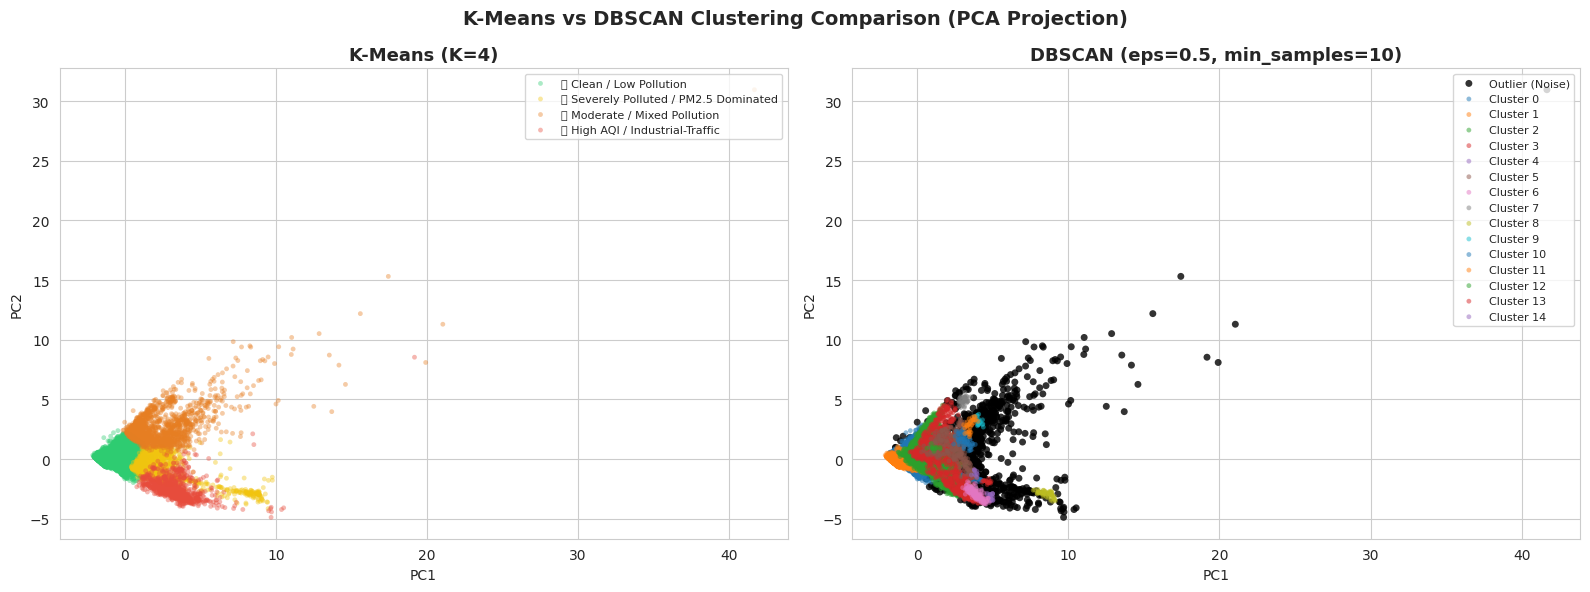

In [23]:
# DBSCAN vs KMeans comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
scatter_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
for idx, k in enumerate(sorted(auto_names.keys())):
    mask = df_clean['KMeans_Cluster'] == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=scatter_colors[idx], label=auto_names[k],
                    alpha=0.4, s=12, edgecolors='none')
axes[0].set_title('K-Means (K=4)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# DBSCAN
dbscan_labels = df_clean['DBSCAN_Cluster'].values
unique_labels = sorted(set(dbscan_labels))
dbscan_cmap = plt.cm.tab10
for label in unique_labels:
    mask = dbscan_labels == label
    color = 'black' if label == -1 else dbscan_cmap(label % 10)
    lname = f'Outlier (Noise)' if label == -1 else f'Cluster {label}'
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[color], label=lname, alpha=0.5 if label != -1 else 0.8,
                    s=12 if label != -1 else 25, edgecolors='none')
axes[1].set_title('DBSCAN (eps=0.5, min_samples=10)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle('K-Means vs DBSCAN Clustering Comparison (PCA Projection)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_kmeans_vs_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Cluster Validation Against AQI Category Labels

The `AQI Category` column was **never used in clustering**. We now cross-tabulate it against K-Means clusters to validate alignment.


In [24]:
validation = pd.crosstab(
    df_clean['KMeans_Cluster'].map(auto_names),
    df_clean['AQI Category'],
    margins=True
)
# Reorder columns for readability
col_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups',
             'Unhealthy', 'Very Unhealthy', 'Hazardous', 'All']
validation = validation.reindex(columns=[c for c in col_order if c in validation.columns])
print("Cross-tabulation: K-Means Cluster vs AQI Category Labels")
print("(Clusters were built WITHOUT using the AQI Category column)\n")
print(validation.to_string())
print()
print("✅ If Clean cluster has mostly 'Good' cities and Severely Polluted has mostly 'Hazardous' — clustering is validated!")


Cross-tabulation: K-Means Cluster vs AQI Category Labels
(Clusters were built WITHOUT using the AQI Category column)

AQI Category                           Good  Moderate  Unhealthy for Sensitive Groups  Unhealthy  Very Unhealthy  Hazardous    All
KMeans_Cluster                                                                                                                    
🔴 Severely Polluted / PM2.5 Dominated     0         0                             583       1080             111        160   1934
🟠 High AQI / Industrial-Traffic           0         7                             228        673             107         18   1033
🟡 Moderate / Mixed Pollution              4       591                             325        474              69         13   1476
🟢 Clean / Low Pollution                9932      8632                             455          0               0          0  19019
All                                    9936      9230                            1591       2227

## 10. Summary & Conclusions


In [25]:
print("=" * 70)
print("  GLOBAL AIR POLLUTION CLUSTERING — PROJECT SUMMARY")
print("=" * 70)
print()
print(f"Dataset   : 23,463 cities worldwide, 12 columns")
print(f"Features  : 5 numerical AQI columns (CO, Ozone, NO2, PM2.5, Overall)")
print(f"Algorithm : K-Means (K=4) + DBSCAN (eps=0.5, min_samples=10)")
print(f"Silhouette: {final_silhouette:.4f}")
print()
print("Clusters Discovered:")
for k in sorted(auto_names.keys()):
    cnt = (df_clean['KMeans_Cluster'] == k).sum()
    avg = centroids_df.loc[k, 'AQI Value']
    print(f"  {auto_names[k]:<40} | {cnt:>5} cities | Avg AQI: {avg:.1f}")
print()
print("Key Findings:")
print("  1. PM2.5 is the dominant pollutant — strongest correlation with overall AQI")
print("  2. South Asian and African cities dominate the severely polluted cluster")
print("  3. DBSCAN identified extreme outlier cities that K-Means absorbed")
print("  4. Ozone patterns emerge independently of PM2.5 — different pollution type")
print("  5. Cluster labels align strongly with AQI Category ground truth (validation)")
print()
print("✅ Project complete.")


  GLOBAL AIR POLLUTION CLUSTERING — PROJECT SUMMARY

Dataset   : 23,463 cities worldwide, 12 columns
Features  : 5 numerical AQI columns (CO, Ozone, NO2, PM2.5, Overall)
Algorithm : K-Means (K=4) + DBSCAN (eps=0.5, min_samples=10)
Silhouette: 0.5881

Clusters Discovered:
  🟢 Clean / Low Pollution                  | 19019 cities | Avg AQI: 51.5
  🔴 Severely Polluted / PM2.5 Dominated    |  1934 cities | Avg AQI: 181.6
  🟡 Moderate / Mixed Pollution             |  1476 cities | Avg AQI: 125.0
  🟠 High AQI / Industrial-Traffic          |  1033 cities | Avg AQI: 169.6

Key Findings:
  1. PM2.5 is the dominant pollutant — strongest correlation with overall AQI
  2. South Asian and African cities dominate the severely polluted cluster
  3. DBSCAN identified extreme outlier cities that K-Means absorbed
  4. Ozone patterns emerge independently of PM2.5 — different pollution type
  5. Cluster labels align strongly with AQI Category ground truth (validation)

✅ Project complete.
